In [63]:
print('Yagnik')



Yagnik


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('vgsales.csv')

print(df['Year'].isnull().sum())

df['Year'] = df['Year'].fillna(df['Year'].median())

df['Year'] = df['Year'].astype(int)

df['Year']

271


,Year
0,2006
1,1985
2,2008
3,2009
4,1996
...,...
16593,2002
16594,2003
16595,2008
16596,2010


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16598 non-null  int64  
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB


In [66]:
(df['EU_Sales'] < 0 ).any()
(df['NA_Sales'] < 0 ).any()
(df['JP_Sales'] < 0 ).any()
(df['Other_Sales'] < 0 ).any()
(df['Global_Sales'] < 0 ).any()


np.False_

In [67]:
df['Calculated_Global'] = (df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales'])

print(df[['Global_Sales','Calculated_Global']].head())

matches = np.isclose(df['Global_Sales'],df['Calculated_Global'])

print(matches.all())

mismatch = df[~matches]

print(mismatch[['Name','Global_Sales','Calculated_Global']])



   Global_Sales  Calculated_Global
0         82.74              82.74
1         40.24              40.24
2         35.82              35.83
3         33.00              33.00
4         31.37              31.38
False
                                                   Name  Global_Sales  \
2                                        Mario Kart Wii         35.82   
4                              Pokemon Red/Pokemon Blue         31.37   
7                                              Wii Play         29.02   
8                             New Super Mario Bros. Wii         28.62   
10                                           Nintendogs         24.76   
...                                                 ...           ...   
16193                                    K-1 Grand Prix          0.01   
16222                           Carmageddon: Max Damage          0.01   
16284                  The Ultimate Battle of the Sexes          0.01   
16465             Help Wanted: 50 Wacky Jobs (jp sales

**Phase 3: Descriptive Statistics**

What is the average global sales?

In [68]:
avg_global_Sales = df['Global_Sales'].mean()
avg_global_Sales

np.float64(0.5374406555006628)

What is the median global sales?

In [69]:
df['Global_Sales'].median()

0.17

What is the standard deviation?

In [70]:
df['Global_Sales'].std()

1.5550279355699022

Which game has the highest global sales?

In [71]:
highest_game = df.loc[df['Global_Sales'].idxmax()]

print(highest_game[['Name','Global_Sales']])

Name            Wii Sports
Global_Sales         82.74
Name: 0, dtype: object


Which game has the lowest global sales?

In [72]:
lowest_game = df.loc[df['Global_Sales'].idxmin()]

print(lowest_game[['Name','Global_Sales']])

Name            Turok
Global_Sales     0.01
Name: 15980, dtype: object


What are the top 10 best-selling games?

In [73]:
top_10 = df.sort_values(by = 'Global_Sales',ascending = False).head(10)

print(top_10[['Name','Global_Sales']])

                        Name  Global_Sales
0                 Wii Sports         82.74
1          Super Mario Bros.         40.24
2             Mario Kart Wii         35.82
3          Wii Sports Resort         33.00
4   Pokemon Red/Pokemon Blue         31.37
5                     Tetris         30.26
6      New Super Mario Bros.         30.01
7                   Wii Play         29.02
8  New Super Mario Bros. Wii         28.62
9                  Duck Hunt         28.31


What are the bottom 10 best-selling games?

In [74]:
bottom_10 = df.sort_values(by = 'Global_Sales',ascending=True).head(10)

print(bottom_10[['Name','Global_Sales']])

                                       Name  Global_Sales
16584                      Bust-A-Move 3000          0.01
16583                        Carmageddon 64          0.01
16582                       Planet Monsters          0.01
16581                             Fit & Fun          0.01
16580                             Real Rode          0.01
16579                     PGA European Tour          0.01
16520  Tengai Makyo: Dai Yon no Mokushiroku          0.01
16519            Bakumatsu Rock: Ultra Soul          0.01
16518                      Crossroad Crisis          0.01
16517          Teenage Mutant Ninja Turtles          0.01


Quartiles

In [75]:
print('1st quartile',df['Global_Sales'].quantile(0.25))
print('2nd quartile',df['Global_Sales'].quantile(0.50))
print('3nd quartile',df['Global_Sales'].quantile(0.75))

1st quartile 0.06
2nd quartile 0.17
3nd quartile 0.47


Detect outliers using IQR

In [76]:
Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Global_Sales'] < lower) | (df['Global_Sales'] > upper)]

print('Number of outliers:', len(outliers))
print(outliers[['Name', 'Global_Sales']].head())

Number of outliers: 1893
                       Name  Global_Sales
0                Wii Sports         82.74
1         Super Mario Bros.         40.24
2            Mario Kart Wii         35.82
3         Wii Sports Resort         33.00
4  Pokemon Red/Pokemon Blue         31.37


**Phase 4: Univariate Analysis**

Distribution of Global Sales

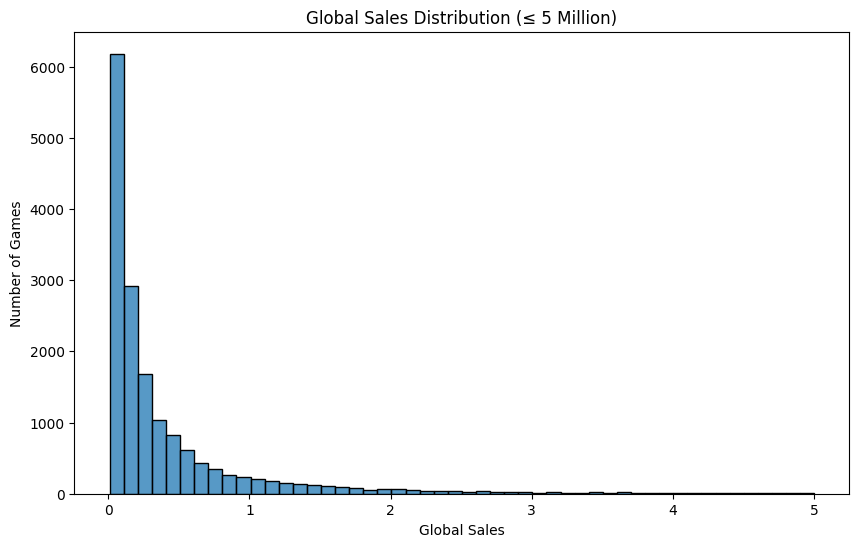

In [77]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df[df["Global_Sales"] <= 5]["Global_Sales"],
    bins=50
)

plt.title("Global Sales Distribution (≤ 5 Million)")
plt.xlabel("Global Sales")
plt.ylabel("Number of Games")

plt.show()

Distribution of NA Sales

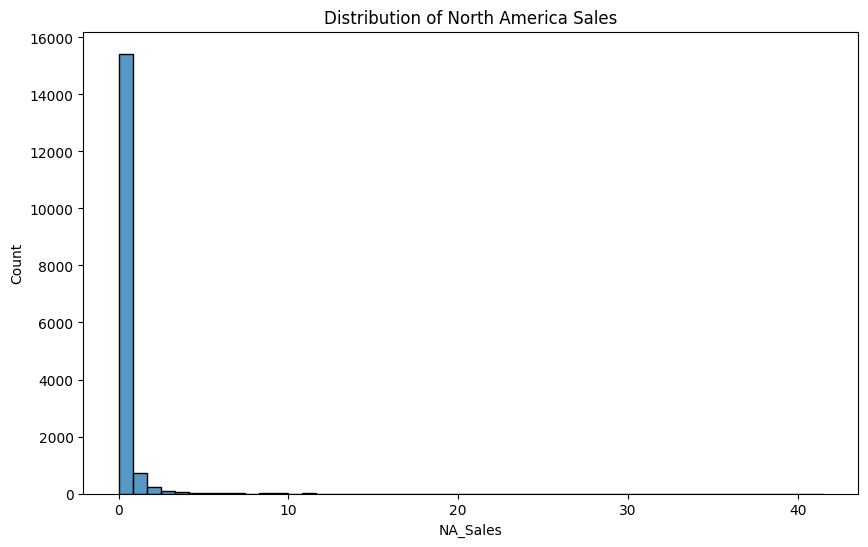

In [78]:
plt.figure(figsize=(10,6))
sns.histplot(x='NA_Sales',data=df,bins=50)
plt.title("Distribution of North America Sales")
plt.show()

Distribution of EU Sales

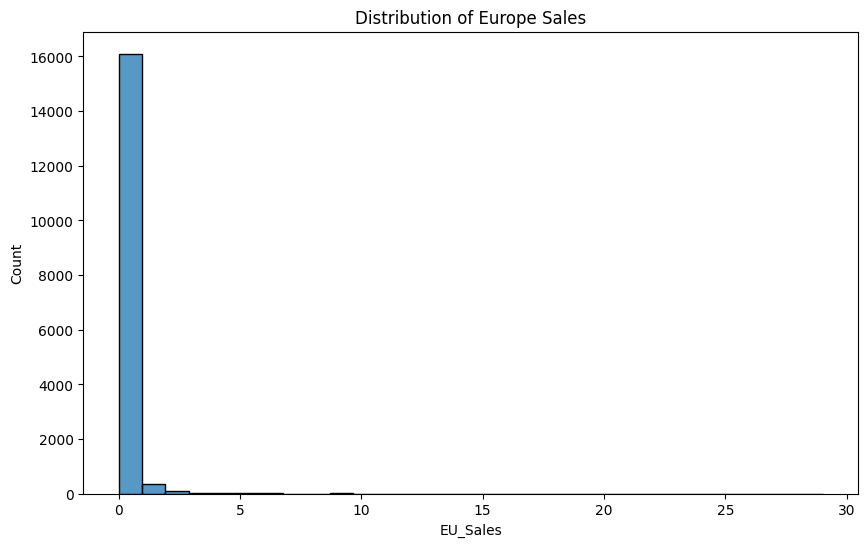

In [79]:
plt.figure(figsize=(10, 6))
sns.histplot(x='EU_Sales',data=df,bins=30)
plt.title('Distribution of Europe Sales')
plt.show()

Count of games by Genre

/tmp/ipykernel_4560/33873157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Genre',data=df,order=df['Genre'].value_counts().index,palette='rainbow')


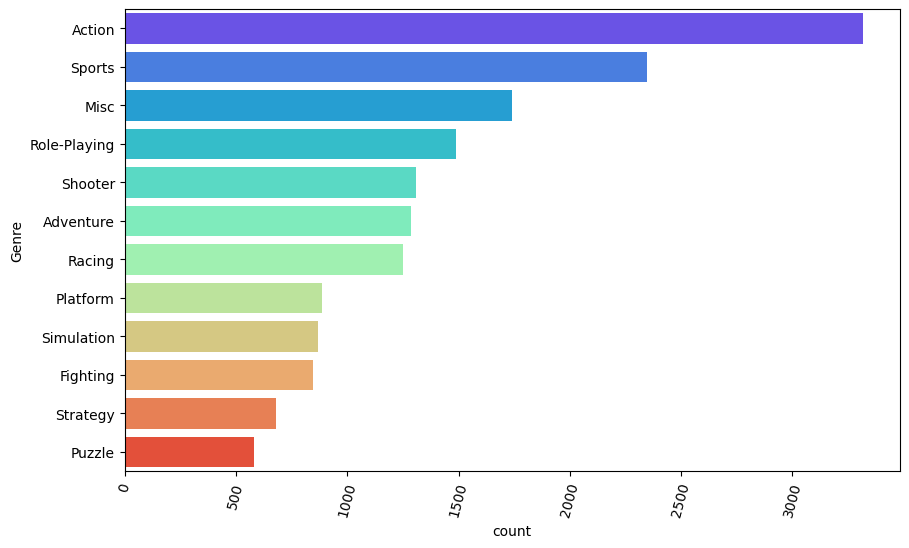

In [80]:
plt.figure(figsize=(10,6))
sns.countplot(y='Genre',data=df,order=df['Genre'].value_counts().index,palette='rainbow')
plt.xticks(rotation = 75)
plt.show()

Count of games by Platform

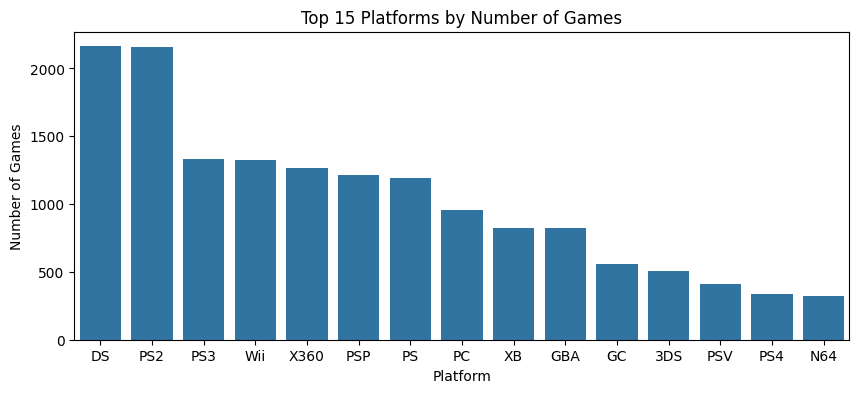

In [81]:
byplatform = df['Platform'].value_counts().head(15)
plt.figure(figsize=(10,4))
sns.barplot(x=byplatform.index,y=byplatform.values)
plt.title("Top 15 Platforms by Number of Games")
plt.ylabel("Number of Games")
plt.xlabel("Platform")
plt.show()


Games released per year

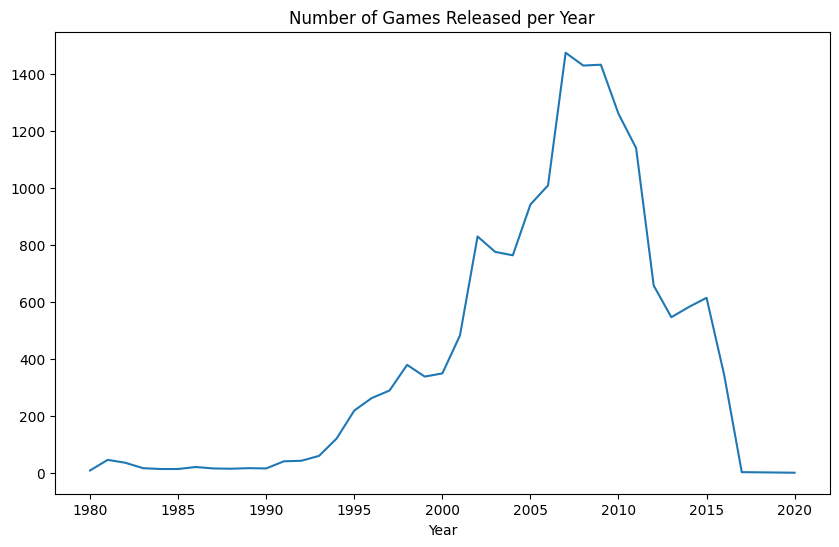

In [82]:
groupbyyear = df.groupby('Year')['Name'].count()
plt.figure(figsize=(10,6))
sns.lineplot(x=groupbyyear.index,y=groupbyyear.values)
plt.title("Number of Games Released per Year")
plt.show()

**Phase 5: Bivariate Analysis**

Which genre has the highest average global sales?

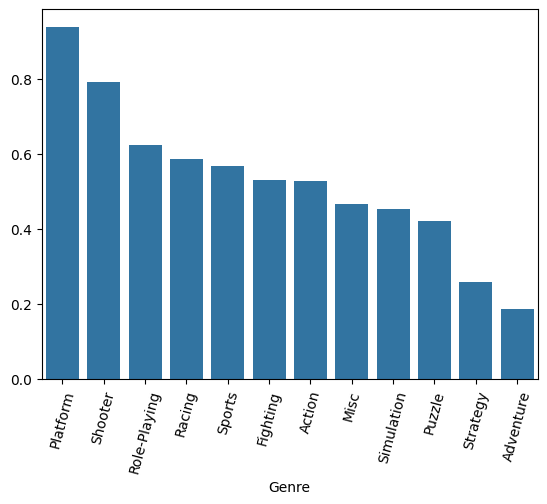

In [83]:

groupbygenre = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
sns.barplot(x=groupbygenre.index,y=groupbygenre.values)
plt.xticks(rotation = 75)
plt.show()

Which genre has the highest total global sales?

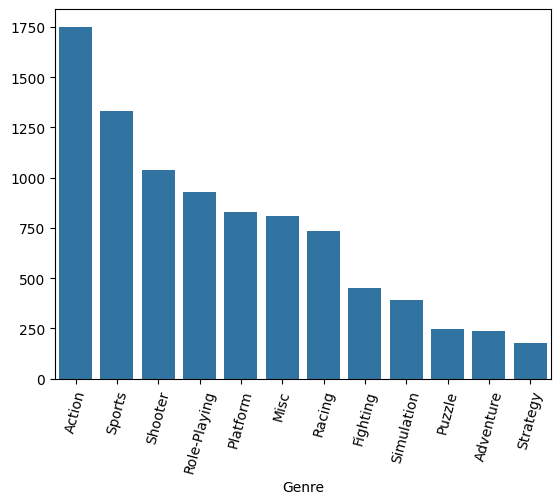

In [84]:
groupbytotalsales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

sns.barplot(x=groupbytotalsales.index,y=groupbytotalsales.values)
plt.xticks(rotation=75)
plt.show()

Which platform sold the most globally?

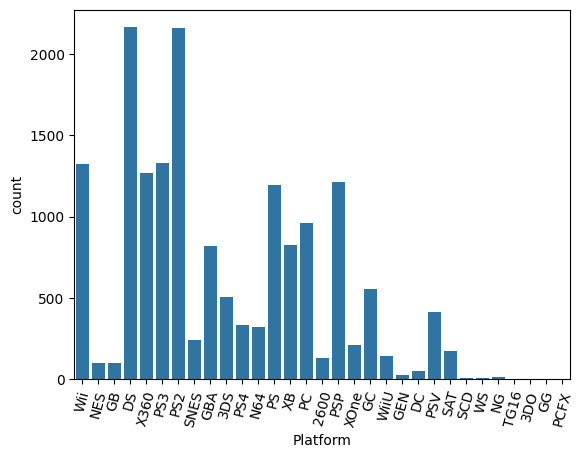

In [85]:
sns.countplot(x='Platform',data=df)
plt.xticks(rotation=75)
plt.show()

Which platform has the highest average sales per game?

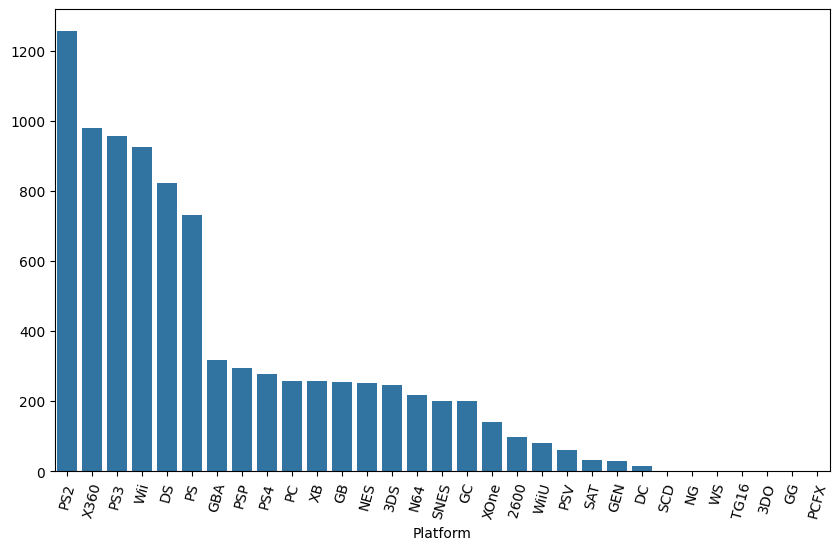

In [86]:
plt.figure(figsize=(10,6))
groupbyplatform = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
sns.barplot(x=groupbyplatform.index,y=groupbyplatform.values)
plt.xticks(rotation=75)
plt.show()

Which publisher has released the most games?

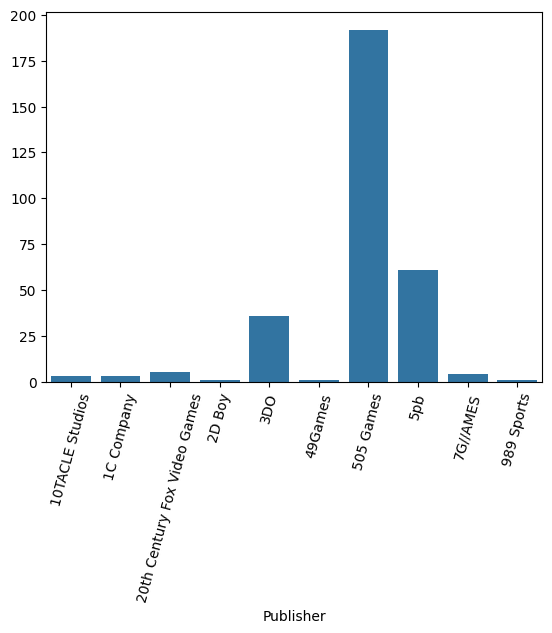

In [87]:
groupbypublisher1 = df.groupby('Publisher')['Name'].count().head(10)
sns.barplot(x=groupbypublisher1.index,y=groupbypublisher1.values)
plt.xticks(rotation=75)
plt.show()

Which publisher earned the highest total global sales?

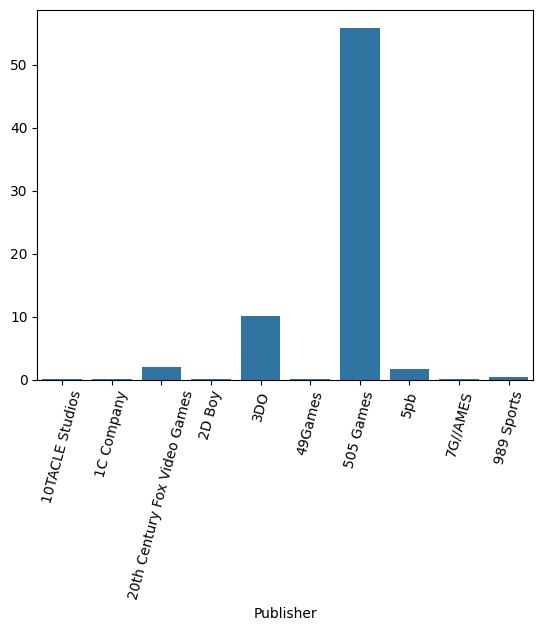

In [88]:
groupbypublisher1 = df.groupby('Publisher')['Global_Sales'].sum().head(10)
sns.barplot(x=groupbypublisher1.index,y=groupbypublisher1.values)
plt.xticks(rotation=75)
plt.show()

Which year had the highest game sales?

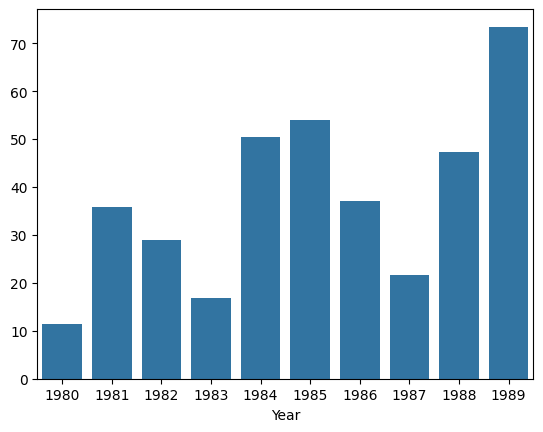

In [89]:
year = df.groupby('Year')['Global_Sales'].sum().head(10)
sns.barplot(x=year.index,y=year.values)
plt.show()


Phase 6 — Correlation Analysis

Correlation matrix

In [90]:
sales_columns = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']
correaltion = df[sales_columns].corr()
correaltion

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.000000,0.767727,0.449787,0.634737,0.941047
EU_Sales,0.767727,1.000000,0.435584,0.726385,0.902836
JP_Sales,0.449787,0.435584,1.000000,0.290186,0.611816
Other_Sales,0.634737,0.726385,0.290186,1.000000,0.748331
Global_Sales,0.941047,0.902836,0.611816,0.748331,1.000000


Heatmap

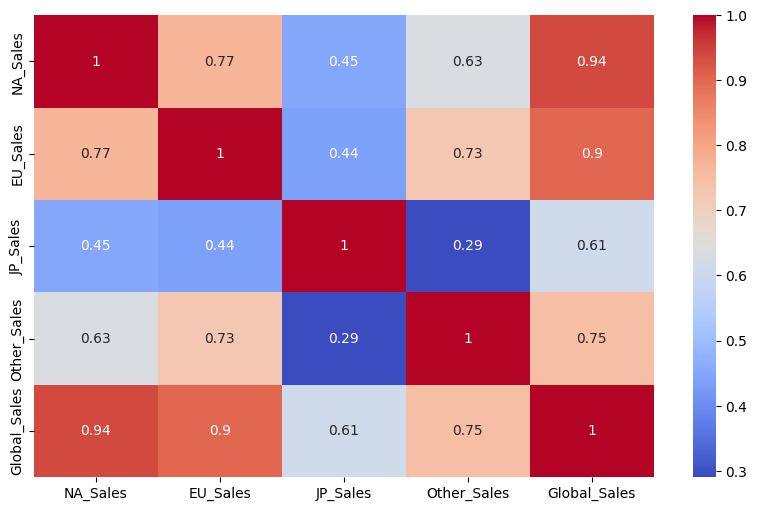

In [91]:
plt.figure(figsize=(10,6))
sns.heatmap(correaltion,annot=True,cmap='coolwarm')
plt.show()

NA Sales vs Global Sales

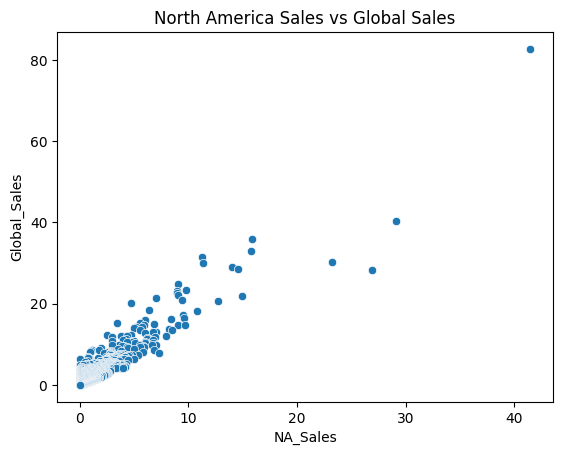

In [92]:
NSvsGlobal = df['NA_Sales'].corr(df['Global_Sales'])
sns.scatterplot(x='NA_Sales',y='Global_Sales',data=df)
plt.title("North America Sales vs Global Sales")

plt.show()

Which region contributes most?

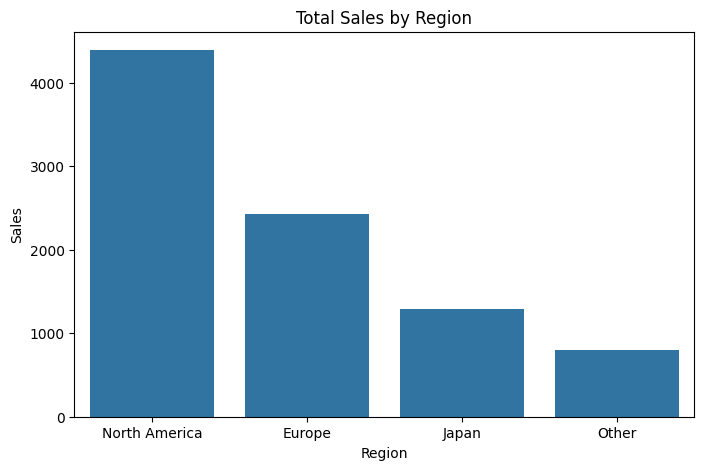

In [93]:
region_sales = {
    "North America":df['NA_Sales'].sum(),
    "Europe":df['EU_Sales'].sum(),
    "Japan":df['JP_Sales'].sum(),
    "Other":df['Other_Sales'].sum()

}

region_sales = pd.Series(region_sales)
plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

**Phase 7: Time Series Exploration**

Total global sales by year.

/tmp/ipykernel_4560/2794958992.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=groupbyyear3.index,y=groupbyyear3.values,palette='rainbow')


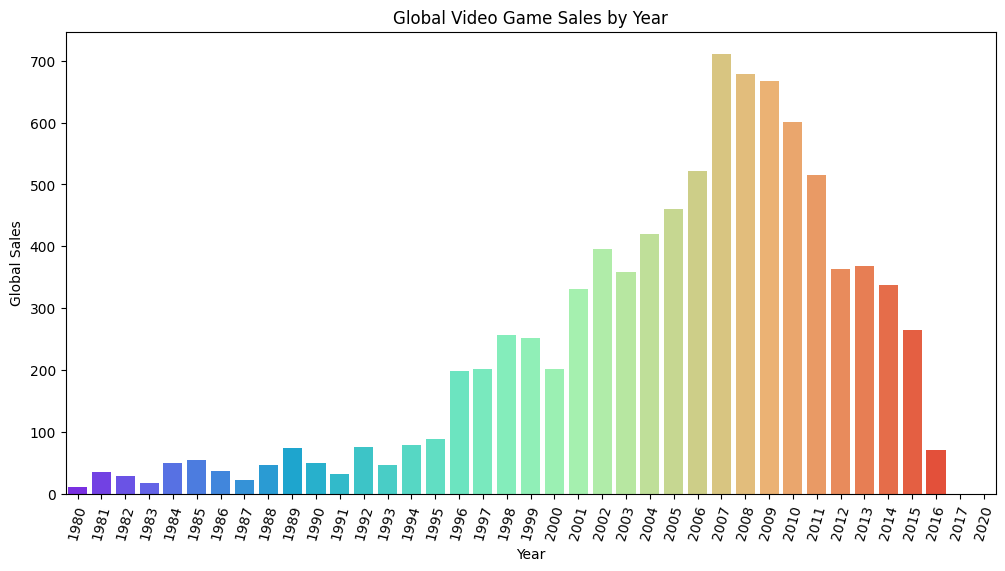

In [94]:
groupbyyear3 = df.groupby('Year')['Global_Sales'].sum()
plt.figure(figsize=(12, 6))


sns.barplot(x=groupbyyear3.index,y=groupbyyear3.values,palette='rainbow')
plt.xticks(rotation=75)
plt.title("Global Video Game Sales by Year")
plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.show()

Number of games released by year.

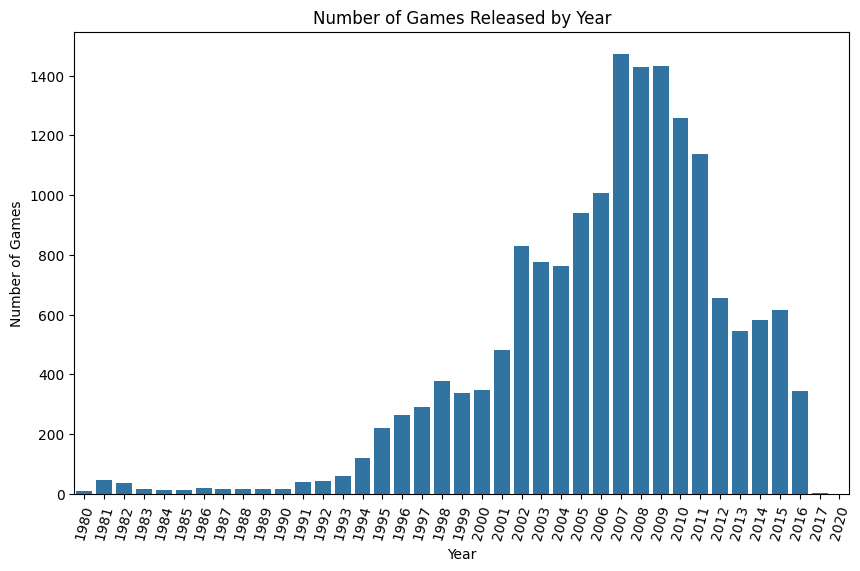

In [95]:
groupbygames = df.groupby('Year')['Name'].count()
plt.figure(figsize=(10,6))
sns.barplot(x=groupbygames.index,y=groupbyyear.values)
plt.xticks(rotation=75)
plt.title("Number of Games Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.show()


Average sales per game by year.

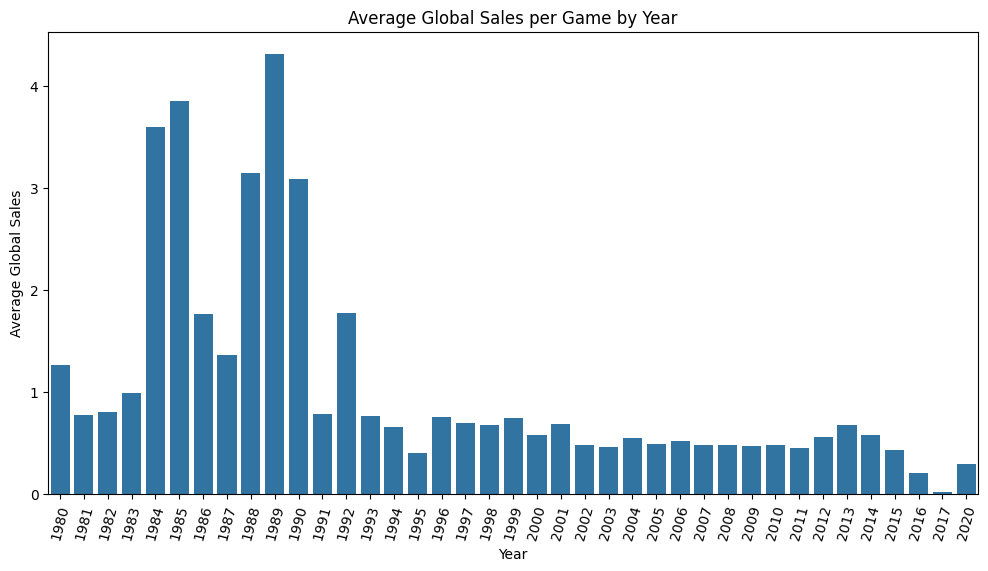

In [96]:
groupbygameyear = df.groupby('Year')['Global_Sales'].mean()
plt.figure(figsize=(12, 6))

sns.barplot(x=groupbygameyear.index,y=groupbygameyear.values)
plt.xticks(rotation=75)
plt.title("Average Global Sales per Game by Year")
plt.xlabel("Year")
plt.ylabel("Average Global Sales")
plt.show()

Top-selling genre each year.

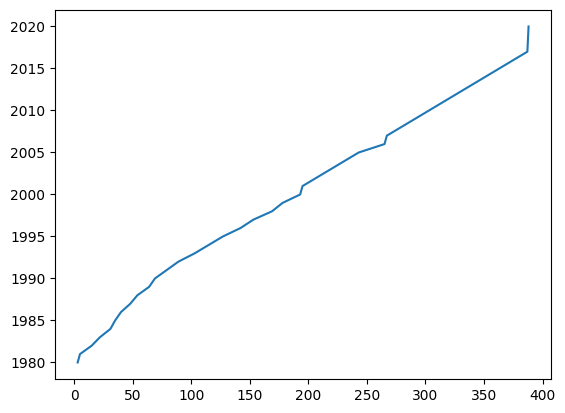

In [97]:
genre_year_sales = (
    df.groupby(["Year", "Genre"])["Global_Sales"]
    .sum()
    .reset_index()
)

top_genre_each_year = (
    genre_year_sales
    .loc[
        genre_year_sales.groupby("Year")["Global_Sales"].idxmax()
    ]
)

plt.plot(top_genre_each_year['Year'])

Top-selling platform each year

In [98]:
platform_year_sales = (
    df.groupby(["Year", "Platform"])["Global_Sales"]
    .sum()
    .reset_index()
)

top_platform_each_year = (
    platform_year_sales
    .loc[
        platform_year_sales.groupby("Year")["Global_Sales"].idxmax()
    ]
)

print(top_platform_each_year)

     Year Platform  Global_Sales
0    1980     2600         11.38
1    1981     2600         35.77
2    1982     2600         28.86
4    1983      NES         10.96
6    1984      NES         50.09
9    1985      NES         53.44
12   1986      NES         36.41
14   1987      NES         19.76
17   1988      NES         45.01
20   1989       GB         64.98
25   1990     SNES         26.16
29   1991     SNES         16.21
35   1992     SNES         32.98
40   1993     SNES         40.01
50   1994     SNES         35.08
55   1995       PS         35.92
64   1996       PS         94.68
70   1997       PS        136.08
77   1998       PS        169.58
84   1999       PS        144.57
93   2000       PS         96.28
104  2001      PS2        166.43
113  2002      PS2        205.40
119  2003      PS2        184.29
125  2004      PS2        211.78
132  2005      PS2        160.65
143  2006      Wii        137.91
160  2007      Wii        171.87
169  2008      Wii        174.16
177  2009 

**Phase 8 — Regional Market Analysis**

Compare regions

In [99]:
regional_df = pd.DataFrame({
    "Region": [
        "North America",
        "Europe",
        "Japan",
        "Other"
    ],
    "Sales": [
        df["NA_Sales"].sum(),
        df["EU_Sales"].sum(),
        df["JP_Sales"].sum(),
        df["Other_Sales"].sum()
    ]
})

print(regional_df)

          Region    Sales
0  North America  4392.95
1         Europe  2434.13
2          Japan  1291.02
3          Other   797.75


Dominant genre in Japan

<Axes: xlabel='Genre'>

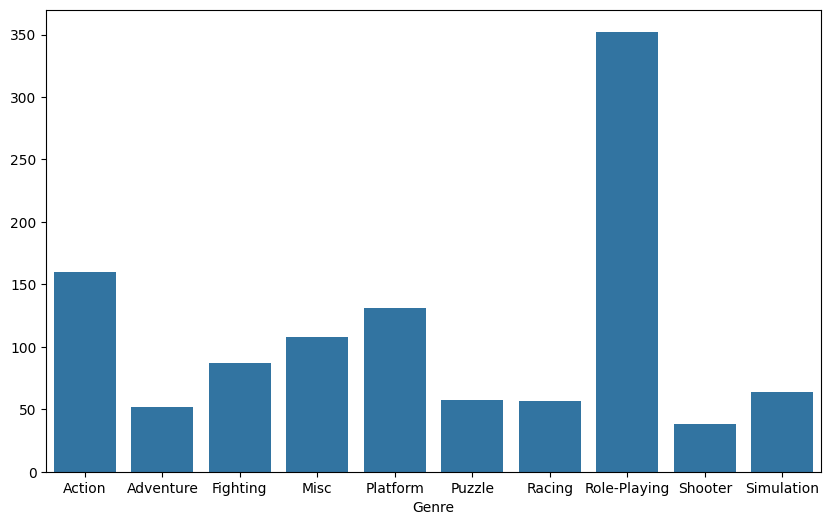

In [100]:
groupbyjapan = df.groupby('Genre')['JP_Sales'].sum().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=groupbyjapan.index,y=groupbyjapan.values)

Dominant genre in North America

<Axes: xlabel='Genre'>

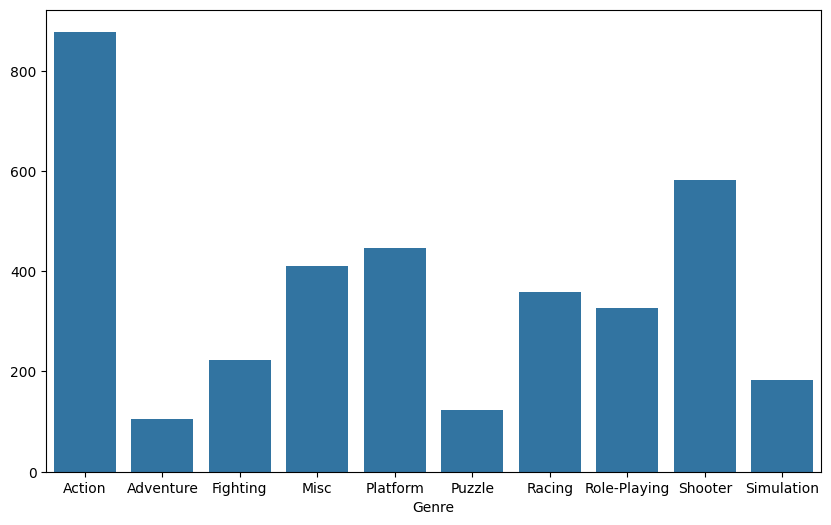

In [101]:
groupbyamerica = df.groupby('Genre')['NA_Sales'].sum().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=groupbyamerica.index,y=groupbyamerica.values)



Strongest platform in Europe

<Axes: xlabel='Platform'>

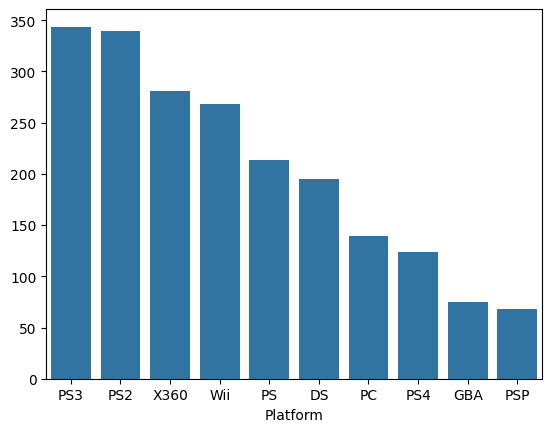

In [102]:
eu_platform_sales =  df.groupby("Platform")["EU_Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=eu_platform_sales.index,y=eu_platform_sales.values)





Best publisher in Japan

<Axes: xlabel='Publisher'>

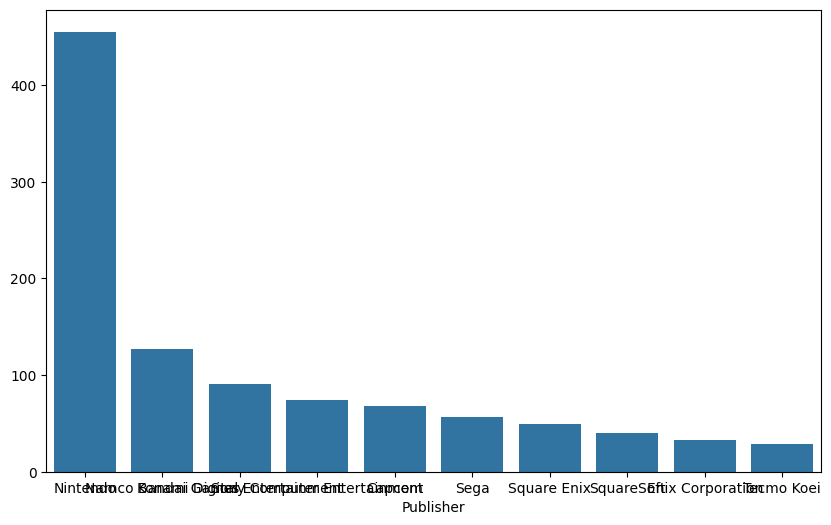

In [103]:
jp_publisher_sales =  df.groupby("Publisher")["JP_Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=jp_publisher_sales.index,y=jp_publisher_sales.values)


**Phase 9 — Advanced Pandas**

Multiple statistics by Genre

In [104]:
genre_statistics = (
    df.groupby("Genre")["Global_Sales"]
    .agg([
        "count",
        "mean",
        "median",
        "max",
        "sum"
    ])
    .sort_values("sum", ascending=False)
)
genre_statistics

,count,mean,median,max,sum
Genre,,,,,
Action,3316,0.528100,0.190,21.40,1751.18
Sports,2346,0.567319,0.220,82.74,1330.93
Shooter,1310,0.791885,0.230,28.31,1037.37
Role-Playing,1488,0.623233,0.185,31.37,927.37
Platform,886,0.938341,0.280,40.24,831.37
Misc,1739,0.465762,0.160,29.02,809.96
Racing,1249,0.586101,0.190,35.82,732.04
Fighting,848,0.529375,0.210,13.04,448.91
Simulation,867,0.452364,0.160,24.76,392.20


Group by Platform and Year

In [105]:
platform_year = (
    df.groupby(["Platform", "Year"])["Global_Sales"]
    .sum()
)

print(platform_year)

Platform  Year
2600      1980    11.38
          1981    35.77
          1982    28.86
          1983     5.83
          1984     0.27
                  ...  
XB        2008     0.18
XOne      2013    18.60
          2014    52.43
          2015    57.66
          2016    12.37
Name: Global_Sales, Length: 247, dtype: float64


Pivot table — Genre vs Platform

In [106]:
genre_platform_pivot = pd.pivot_table(
    df,
    values="Global_Sales",
    index="Genre",
    columns="Platform",
    aggfunc="sum",
    fill_value=0
)

print(genre_platform_pivot)

Platform       2600   3DO    3DS    DC      DS     GB    GBA     GC    GEN  \
Genre                                                                        
Action        29.34  0.00  57.02  1.26  115.56   7.92  55.76  37.84   2.74   
Adventure      1.70  0.06   4.81  2.50   47.29  17.16  14.68   5.93   0.19   
Fighting       1.24  0.00  10.46  1.83    7.20   0.00   4.21  18.43   5.90   
Misc           3.58  0.00  10.48  0.00  137.76  13.35  36.25  16.73   0.03   
Platform      13.27  0.00  32.23  2.54   77.45  54.91  78.30  28.66  15.45   
Puzzle        14.68  0.02   5.57  0.00   84.29  47.47  12.92   4.70   0.00   
Racing         2.91  0.00  14.49  2.65   38.64   4.55  18.80  21.89   0.26   
Role-Playing   0.00  0.00  75.74  0.68  126.85  88.24  64.21  13.15   0.27   
Shooter       26.48  0.00   1.29  0.33    8.20   1.20   3.60  13.63   0.13   
Simulation     0.45  0.02  27.08  0.52  132.03   3.55   5.91   8.59   0.00   
Sports         3.43  0.00   6.20  3.66   31.83   9.05  16.41  25

Yearly sales pivot table

In [107]:
year_genre_pivot = pd.pivot_table(
    df,
    values="Global_Sales",
    index="Year",
    columns="Genre",
    aggfunc="sum",
    fill_value=0
)
year_genre_pivot

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Year,,,,,,,,,,,,
1980,0.34,0.00,0.77,2.71,0.00,0.00,0.00,0.00,7.07,0.00,0.49,0.00
1981,14.84,0.00,0.00,0.00,6.93,2.24,0.48,0.00,10.04,0.45,0.79,0.00
1982,6.52,0.00,0.00,0.87,5.03,10.03,1.57,0.00,3.79,0.00,1.05,0.00
1983,2.86,0.40,0.00,2.14,6.93,0.78,0.00,0.00,0.48,0.00,3.20,0.00
1984,1.85,0.00,0.00,1.45,0.69,3.14,5.95,0.00,31.10,0.00,6.18,0.00
1985,3.52,0.00,1.05,0.00,43.17,3.21,0.00,0.00,1.00,0.03,1.96,0.00
1986,13.74,0.00,0.00,0.00,9.39,0.00,1.96,2.52,3.89,0.00,5.57,0.00
1987,1.12,4.38,5.42,0.00,1.74,0.00,0.00,4.65,0.71,0.00,3.72,0.00
1988,1.75,0.00,0.00,0.00,27.73,5.58,2.14,5.88,0.51,0.03,3.60,0.00


agg() with multiple statistics

In [108]:
publisher_statistics = (
    df.groupby("Publisher")
    .agg(
        Total_Games=("Name", "count"),
        Total_Sales=("Global_Sales", "sum"),
        Average_Sales=("Global_Sales", "mean"),
        Maximum_Sales=("Global_Sales", "max")
    )
    .sort_values("Total_Sales", ascending=False)
)

print(publisher_statistics.head(20))

                                        Total_Games  Total_Sales  \
Publisher                                                          
Nintendo                                        703      1786.56   
Electronic Arts                                1351      1110.32   
Activision                                      975       727.46   
Sony Computer Entertainment                     683       607.50   
Ubisoft                                         921       474.72   
Take-Two Interactive                            413       399.54   
THQ                                             715       340.77   
Konami Digital Entertainment                    832       283.64   
Sega                                            639       272.99   
Namco Bandai Games                              932       254.09   
Microsoft Game Studios                          189       245.79   
Capcom                                          381       200.89   
Atari                                           

**Phase 10 — Feature Engineering**

North America percentage

In [109]:
df['NA_Percentage'] = (df['NA_Sales'] / df['Global_Sales']) * 100
df['NA_Percentage']

,NA_Percentage
0,50.145033
1,72.266402
2,44.249023
3,47.727273
4,35.926044
...,...
16593,100.000000
16594,100.000000
16595,0.000000
16596,0.000000


Regional percentages

In [110]:
df["EU_Percentage"] = (
    df["EU_Sales"] / df["Global_Sales"]
) * 100

df["JP_Percentage"] = (
    df["JP_Sales"] / df["Global_Sales"]
) * 100

df["Other_Percentage"] = (
    df["Other_Sales"] / df["Global_Sales"]
) * 100

print(
    df[
        [
            "NA_Percentage",
            "EU_Percentage",
            "JP_Percentage",
            "Other_Percentage"
        ]
    ].head()
)

   NA_Percentage  EU_Percentage  JP_Percentage  Other_Percentage
0      50.145033      35.073725       4.556442         10.224801
1      72.266402       8.896620      16.923459          1.913519
2      44.249023      35.957566      10.580681          9.240648
3      47.727273      33.363636       9.939394          8.969697
4      35.926044      28.339178      32.578897          3.187759


Classify games

In [111]:
def classify_game(sales):
  if sales > 10:
    return 'BlockBuster'
  elif sales >= 1:
    return 'Hit'
  elif sales >= .1:
    return 'Average'
  else:
    return 'Low'


df["Sales_Category"] = df["Global_Sales"].apply(classify_game)

df['Sales_Category']

,Sales_Category
0,BlockBuster
1,BlockBuster
2,BlockBuster
3,BlockBuster
4,BlockBuster
...,...
16593,Low
16594,Low
16595,Low
16596,Low


Count categories

In [112]:
category_counts = df["Sales_Category"].value_counts()

print(category_counts)

Sales_Category
Average        8736
Low            5781
Hit            2019
BlockBuster      62
Name: count, dtype: int64


Visualize categories

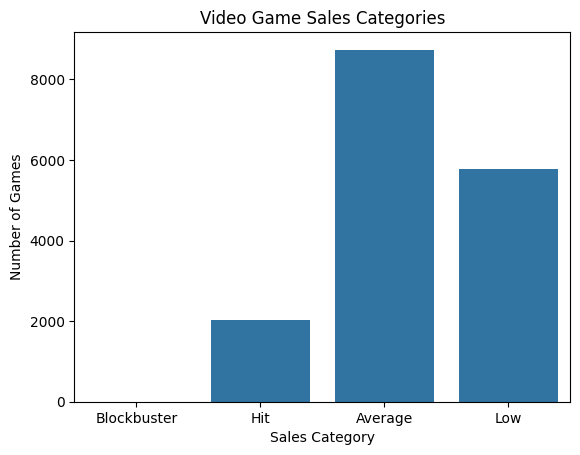

In [113]:
sns.countplot(
    data=df,
    x="Sales_Category",
    order=[
        "Blockbuster",
        "Hit",
        "Average",
        "Low"
    ]
)

plt.title("Video Game Sales Categories")
plt.xlabel("Sales Category")
plt.ylabel("Number of Games")

plt.show()

Phase 11 — Business Insights

Which genre should a company invest in?

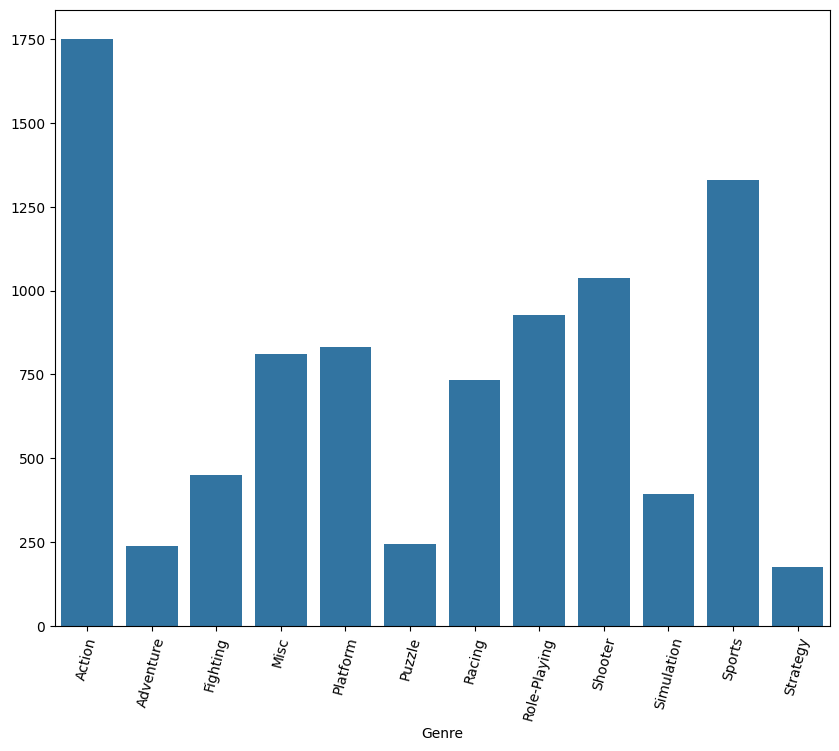

In [114]:
investingenre = df.groupby('Genre')['Global_Sales'].sum()
plt.figure(figsize=(10,8))
sns.barplot(x=investingenre.index,y=investingenre.values)
plt.xticks(rotation=75)
plt.show()

Which platform has the strongest market?

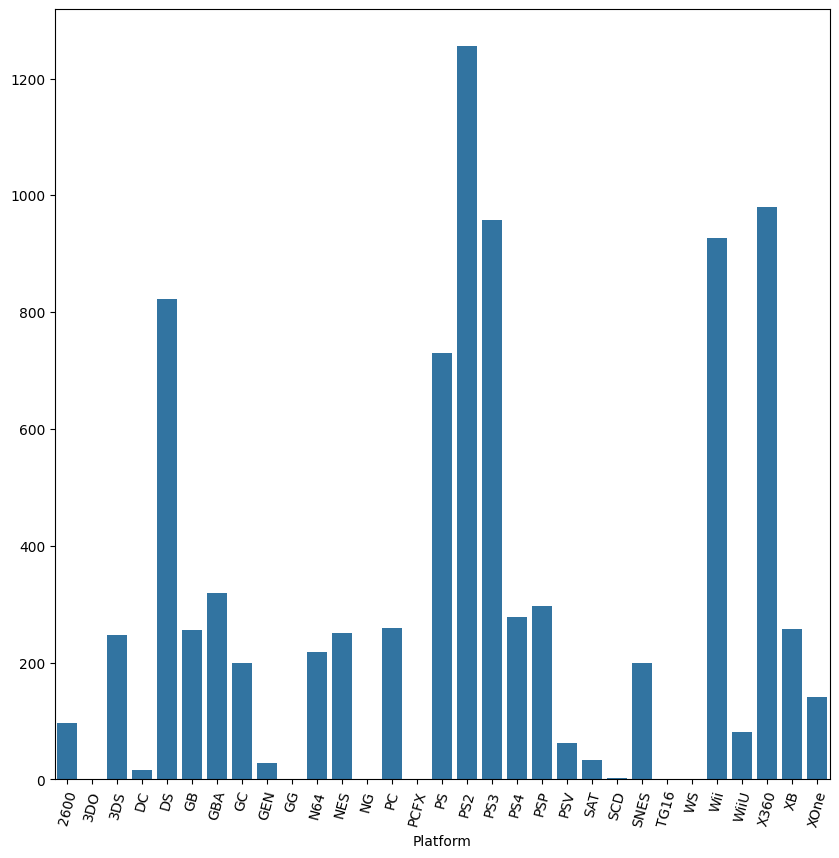

In [115]:
strongmarketbasedonplatform = df.groupby('Platform')['Global_Sales'].sum()
plt.figure(figsize=(10,10))
sns.barplot(x=strongmarketbasedonplatform.index,y=strongmarketbasedonplatform.values)
plt.xticks(rotation=75)
plt.show()

Which region generates the most sales?

In [116]:
print(regional_df.sort_values("Sales", ascending=False))

          Region    Sales
0  North America  4392.95
1         Europe  2434.13
2          Japan  1291.02
3          Other   797.75


**Phase 12 — Challenge Problems**

Top 5 publishers in each region

In [117]:
for column in [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales"
]:

    print("\n", column)

    print(
        df.groupby("Publisher")[column]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )


 NA_Sales
Publisher
Nintendo                       816.87
Electronic Arts                595.07
Activision                     429.70
Sony Computer Entertainment    265.22
Ubisoft                        253.43
Name: NA_Sales, dtype: float64

 EU_Sales
Publisher
Nintendo                       418.74
Electronic Arts                371.27
Activision                     215.53
Sony Computer Entertainment    187.72
Ubisoft                        163.32
Name: EU_Sales, dtype: float64

 JP_Sales
Publisher
Nintendo                        455.42
Namco Bandai Games              127.07
Konami Digital Entertainment     91.30
Sony Computer Entertainment      74.10
Capcom                           68.08
Name: JP_Sales, dtype: float64

 Other_Sales
Publisher
Electronic Arts                129.77
Nintendo                        95.33
Sony Computer Entertainment     80.45
Activision                      75.34
Take-Two Interactive            55.24
Name: Other_Sales, dtype: float64


Best-selling game in each genre

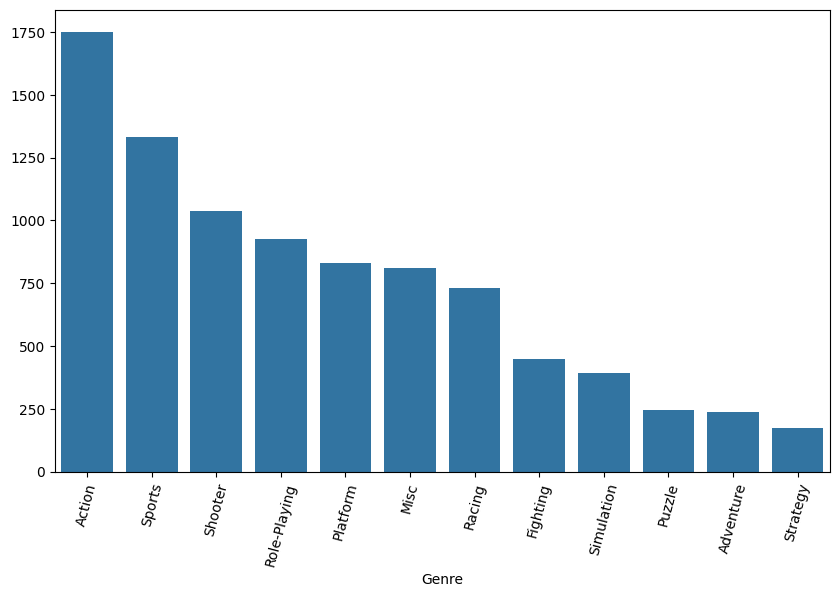

In [118]:
bestsellinggame = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=bestsellinggame.index,y=bestsellinggame.values)
plt.xticks(rotation=75)
plt.show()

 Best-selling game on each platform

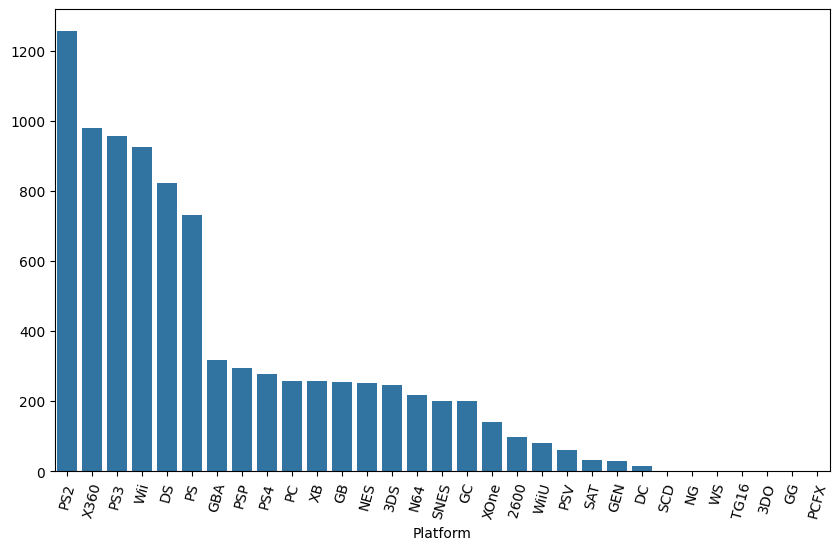

In [119]:
bestsellinggamebyplatform = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=bestsellinggamebyplatform.index,y=bestsellinggamebyplatform.values)
plt.xticks(rotation=75)
plt.show()

Top 3 games for every year

<Axes: xlabel='Year'>

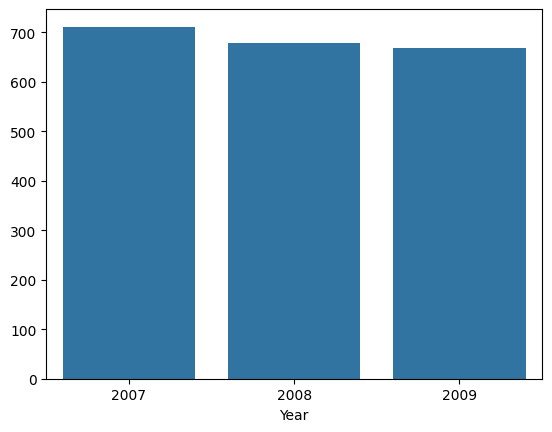

In [120]:
bestbyyear = df.groupby('Year')['Global_Sales'].sum().sort_values(ascending=False).head(3)
sns.barplot(x=bestbyyear.index,y=bestbyyear.values)


# **EXTRA WORK**

Which genre has the highest sales in each region?

In [121]:
colu = ['NA_Sales','EU_Sales','Other_Sales','JP_Sales']
bygenre = df.groupby('Genre')[colu].sum()
highest_by_region = bygenre.idxmax()
highest_by_region

,0
NA_Sales,Action
EU_Sales,Action
Other_Sales,Action
JP_Sales,Role-Playing


Which platform was dominant in each year?

In [122]:
byplatform = df.groupby(['Platform','Year'])['Global_Sales'].sum()
dominanat_platform = byplatform.groupby('Year').idxmax()
dominanat_platform

,Global_Sales
Year,
1980,"(2600, 1980)"
1981,"(2600, 1981)"
1982,"(2600, 1982)"
1983,"(NES, 1983)"
1984,"(NES, 1984)"
1985,"(NES, 1985)"
1986,"(NES, 1986)"
1987,"(NES, 1987)"
1988,"(NES, 1988)"


What are the top 3 publishers for each region?

In [123]:
colu = ['EU_Sales','JP_Sales','Other_Sales','NA_Sales']
bypublishers = df.groupby('Publisher')[colu].sum()
for region in colu:
  print(f'\nTop3 publishers in {region}')
  print(bypublishers[region].sort_values(ascending=False).head(3))


Top3 publishers in EU_Sales
Publisher
Nintendo           418.74
Electronic Arts    371.27
Activision         215.53
Name: EU_Sales, dtype: float64

Top3 publishers in JP_Sales
Publisher
Nintendo                        455.42
Namco Bandai Games              127.07
Konami Digital Entertainment     91.30
Name: JP_Sales, dtype: float64

Top3 publishers in Other_Sales
Publisher
Electronic Arts                129.77
Nintendo                        95.33
Sony Computer Entertainment     80.45
Name: Other_Sales, dtype: float64

Top3 publishers in NA_Sales
Publisher
Nintendo           816.87
Electronic Arts    595.07
Activision         429.70
Name: NA_Sales, dtype: float64


Which genre has the highest average sales but relatively few games?

In [129]:
game_count = df.groupby('Genre')['Name'].count()
avg_sales = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)

genre_starts = pd.DataFrame({'Game_Count':game_count,'Avg_Sales':avg_sales})

genre_starts = genre_starts.sort_values(ascending=True,by='Game_Count')
genre_starts

,Game_Count,Avg_Sales
Genre,,
Puzzle,582,0.420876
Strategy,681,0.257151
Fighting,848,0.529375
Simulation,867,0.452364
Platform,886,0.938341
Racing,1249,0.586101
Adventure,1286,0.185879
Shooter,1310,0.791885
Role-Playing,1488,0.623233


Which platform has high total sales but low average sales?

In [132]:
high_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
low_avg_sales = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=True)

bygenre = pd.DataFrame({'High_Sales':high_sales,'Low_Avg_Sales':low_avg_sales})

bygenre = bygenre.sort_values(by='Low_Avg_Sales',ascending=True)
bygenre


,High_Sales,Low_Avg_Sales
Genre,,
Adventure,239.04,0.185879
Strategy,175.12,0.257151
Puzzle,244.95,0.420876
Simulation,392.20,0.452364
Misc,809.96,0.465762
Action,1751.18,0.528100
Fighting,448.91,0.529375
Sports,1330.93,0.567319
Racing,732.04,0.586101


Which publisher has the highest average sales per game?

In [140]:
pergame = df.groupby('Publisher')['Name'].count()
high_sales = df.groupby('Publisher')['Global_Sales'].mean().sort_values(ascending=False)

bypublisher = pd.DataFrame({'Per_Game':pergame,'High_Sales':high_sales})
bypublisher = bypublisher.sort_values(by='High_Sales',ascending=False)
bypublisher

,Per_Game,High_Sales
Publisher,,
Palcom,1,4.170000
Red Orb,2,2.620000
Nintendo,703,2.541337
Arena Entertainment,2,2.360000
UEP Systems,1,2.250000
...,...,...
Takuyo,1,0.010000
Media Entertainment,1,0.010000
Michaelsoft,1,0.010000


What percentage of all games are Blockbusters?

In [156]:
blockbuster = (df['Sales_Category'] == 'BlockBuster')
bbt = (blockbuster *100)/df['Name'].count()
bbt

,Sales_Category
0,0.006025
1,0.006025
2,0.006025
3,0.006025
4,0.006025
...,...
16593,0.000000
16594,0.000000
16595,0.000000
16596,0.000000


Which decade had the highest total sales?

Text(0.5, 1.0, 'Highest total sales by decade')

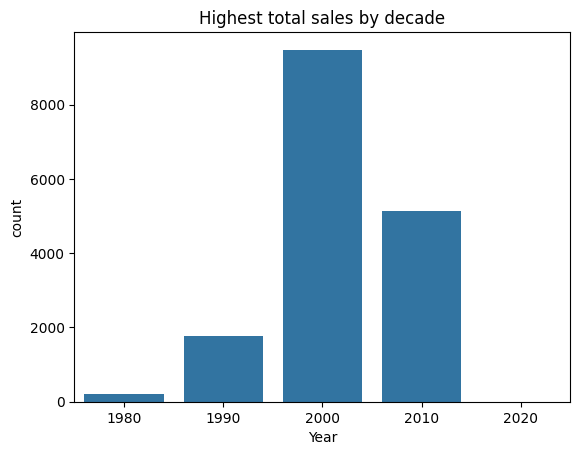

In [162]:
decade = (df['Year']//10)*10
salesbydecade = df.groupby(decade)['Global_Sales'].max()
salesbydecade

sns.countplot(x=decade,data=df)
plt.title('Highest total sales by decade')

Which genre grew the most between two different decades?

In [166]:
differ = salesbydecade.diff().sort_values(ascending=False)
differ


,Global_Sales
Year,
2000,51.37
1990,-8.87
2020,-21.53
2010,-60.92
1980,NaN


If you had to recommend one genre + one platform + one region for a new game, what would you recommend and why?

In [187]:
bestgenre = df.groupby('Genre')['Global_Sales'].sum().idxmax()

bestplatform = df.groupby('Platform')['Global_Sales'].sum().idxmax()

regions = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales']
bestregion = df[regions].sum().idxmax()


bestall = pd.DataFrame({'Best_Genre':[bestgenre],'Best_Platform':[bestplatform],'Best_Region':[bestregion]})
bestall

,Best_Genre,Best_Platform,Best_Region
0,Action,PS2,NA_Sales
